In [17]:
from qiskit import *
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_aer import AerSimulator, StatevectorSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt


In [18]:
#   ────────────────────────────── Configuration ───────────────────────────────
#%matplotlib widget
# Dataset
N          = 1000    # Number of generated points
TEST_SIZE  = 0.2     # Fraction used for test set
SEED       = 1       # Random seed (data split & optimizer init)

# Model
RC         = 4       # Number of circuit layers

# Optimization
MAXITER    = 300     # COBYLA max iterations

# Simulation
USE_NOISE  = True    # True -> noisy AerSimulator | False -> Statevector
NOISE_RATE = 0.005   # Depolarizing error rate per gate
SHOTS      = 1024    # Number of shots

# AdaBoost
N_ESTIMATORS = 5     # Number of weak QNN classifiers in the ensemble


# Data generation

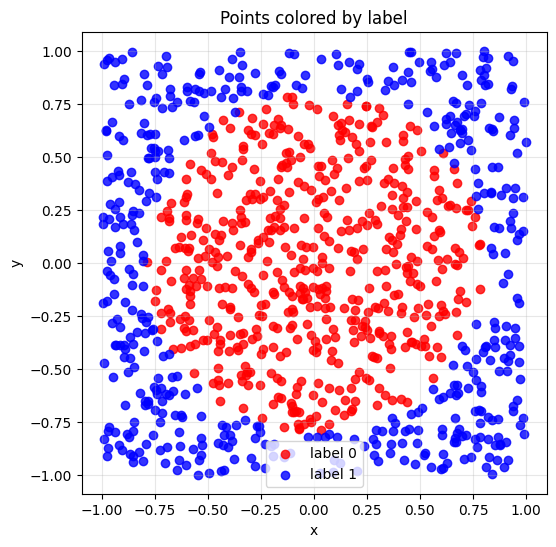

points in label 0: 523
points in label 1: 477


In [19]:
points = np.random.rand(N, 2) * 2 - 1
labels = [0 if x**2 + y**2 < 2/np.pi else 1 for x, y in points]

arr = np.array(points)
lbl = np.array(labels)

plt.figure(figsize=(6, 6))
plt.scatter(arr[lbl == 0, 0], arr[lbl == 0, 1], c="red", label="label 0", alpha=0.8)
plt.scatter(arr[lbl == 1, 0], arr[lbl == 1, 1], c="blue", label="label 1", alpha=0.8)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Points colored by label")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("points in label 0:", np.sum(lbl == 0))
print("points in label 1:", np.sum(lbl == 1))


In [20]:
rng = np.random.default_rng(SEED)

indices   = rng.permutation(len(arr))
split_idx = int(len(arr) * (1 - TEST_SIZE))

train_idx, test_idx = indices[:split_idx], indices[split_idx:]

X_train, X_test = arr[train_idx], arr[test_idx]
y_train, y_test = lbl[train_idx], lbl[test_idx]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)


X_train: (800, 2) y_train: (800,)
X_test : (200, 2) y_test : (200,)


In [21]:
def U_su2(q, theta, omega, x, qubit):
    x3d = [x[0], x[1], 0] # Add a third dimension with value 0
    # phi_i = theta_i + w_i * x_i
    val_0 = theta[0] + omega[0] * x3d[0]
    val_1 = theta[1] + omega[1] * x3d[1]
    val_2 = theta[2] + omega[2] * x3d[2]
    
    q.u(val_0, val_1, val_2, qubit)

In [22]:
def create_circuit(x, theta, omega, measure=True):
    qc = QuantumCircuit(1)
    for i in range(RC):
        qc.h(0)
        U_su2(qc, theta[i], omega[i], x, 0)
    if measure:
        qc.measure_all()
    return qc


In [23]:
theta = [[1, 1, 1] for _ in range(RC)]
omega = [[1, 1, 1] for _ in range(RC)]
qc = create_circuit(X_train[0], theta, omega)
qc.draw()


┌───┐┌─────────────────────┐┌───┐┌─────────────────────┐┌───┐»
     q: ┤ H ├┤ U(0.57125,1.6728,1) ├┤ H ├┤ U(0.57125,1.6728,1) ├┤ H ├»
        └───┘└─────────────────────┘└───┘└─────────────────────┘└───┘»
meas: 1/═════════════════════════════════════════════════════════════»
                                                                     »
«        ┌─────────────────────┐┌───┐┌─────────────────────┐ ░ ┌─┐
«     q: ┤ U(0.57125,1.6728,1) ├┤ H ├┤ U(0.57125,1.6728,1) ├─░─┤M├
«        └─────────────────────┘└───┘└─────────────────────┘ ░ └╥┘
«meas: 1/═══════════════════════════════════════════════════════╩═
«                                                               0

In [24]:
def build_simulator():
    if USE_NOISE:
        nm = NoiseModel()
        nm.add_all_qubit_quantum_error(depolarizing_error(NOISE_RATE, 1), ['u'])
        return AerSimulator(noise_model=nm)
    return StatevectorSimulator()

sv_sim = build_simulator()

def get_probs_batch(circuits):
    """
    Returns a list of (p0, p1) for each circuit.
    Noiseless: exact statevector amplitudes.
    Noisy:     shot-based counts normalised by SHOTS.
    """
    if USE_NOISE:
        meas = [c.copy() for c in circuits]
        for c in meas:
            c.measure_all()
        compiled = transpile(meas, sv_sim)
        results  = sv_sim.run(compiled, shots=SHOTS).result()
        return [
            (results.get_counts(i).get('0', 0) / SHOTS,
             results.get_counts(i).get('1', 0) / SHOTS)
            for i in range(len(meas))
        ]
    else:
        compiled = transpile(circuits, sv_sim)
        results  = sv_sim.run(compiled).result()
        return [
            (float(np.abs(results.get_statevector(i).data[0])**2),
             float(np.abs(results.get_statevector(i).data[1])**2))
            for i in range(len(circuits))
        ]


In [25]:
def cost_function_weighted(params, X_train, y_train):
    theta  = params[:3 * RC].reshape(RC, 3)
    omega  = params[3 * RC:6 * RC].reshape(RC, 3)
    alphas = params[6 * RC:]   # alpha_0, alpha_1

    circuits = [create_circuit(x, theta, omega, measure=False) for x in X_train]
    probs    = get_probs_batch(circuits)

    total_cost = 0.0
    for i, y_target in enumerate(y_train):
        f0, f1     = probs[i]
        y_expected = [1.0, 0.0] if y_target == 0 else [0.0, 1.0]
        total_cost += (alphas[0] * f0 - y_expected[0])**2
        total_cost += (alphas[1] * f1 - y_expected[1])**2

    return 0.5 * (total_cost / len(y_train))


In [26]:
def unpack_params(params):
    theta  = params[:3 * RC].reshape(RC, 3)
    omega  = params[3 * RC:6 * RC].reshape(RC, 3)
    alphas = params[6 * RC:]
    return theta, omega, alphas

def optimize_parameters(X_train, y_train):
    rng  = np.random.default_rng(SEED)
    init = rng.uniform(-np.pi, np.pi, size=6 * RC + 2)

    cache = {"cost": None}
    cost_history = []
    step = {"k": 0}

    def objective(params):
        cost = cost_function_weighted(params, X_train, y_train)
        cache["cost"] = cost
        return cost

    def cb(xk):
        step["k"] += 1
        cost_history.append(cache["cost"])
        print(f"Step {step['k']:03d} | cost = {cache['cost']:.6f}")

    res = minimize(objective, init, method="COBYLA",
                   callback=cb, options={"maxiter": MAXITER})

    theta_opt, omega_opt, _ = unpack_params(res.x)
    print(f"Final cost = {res.fun:.6f}")
    return theta_opt, omega_opt, res, cost_history


In [ ]:
def predict_batch(X, theta, omega):
    circuits = [create_circuit(x, theta, omega, measure=False) for x in X]
    probs    = get_probs_batch(circuits)
    return np.array([0 if p0 >= 0.5 else 1 for p0, _ in probs])

def evaluate_metrics(X, y, theta, omega, positive_label=1):
    y_pred    = predict_batch(X, theta, omega)
    tp        = np.sum((y_pred == positive_label) & (y == positive_label))
    fp        = np.sum((y_pred == positive_label) & (y != positive_label))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    accuracy  = np.mean(y_pred == y)
    return precision, accuracy, y_pred

mode_label = "Noisy" if USE_NOISE else "Noiseless"
sv_sim = build_simulator()

theta_opt, omega_opt, res, cost_history = optimize_parameters(X_train, y_train)
precision_test, accuracy_test, y_pred = evaluate_metrics(X_test, y_test, theta_opt, omega_opt)

print(f"[{mode_label}] Final train cost:", res.fun)
print(f"[{mode_label}] Test precision:", precision_test)
print(f"[{mode_label}] Test accuracy:", accuracy_test)


Step 001 | cost = 1.170764
Step 002 | cost = 1.377637
Step 003 | cost = 0.853038
Step 004 | cost = 0.667077
Step 005 | cost = 0.583352
Step 006 | cost = 0.704884
Step 007 | cost = 1.123681
Step 008 | cost = 0.542410
Step 009 | cost = 0.913780
Step 010 | cost = 0.722747
Step 011 | cost = 0.777577
Step 012 | cost = 0.540934
Step 013 | cost = 0.622322
Step 014 | cost = 0.539515
Step 015 | cost = 0.547443
Step 016 | cost = 0.541255
Step 017 | cost = 0.693840
Step 018 | cost = 0.610348
Step 019 | cost = 0.540664
Step 020 | cost = 0.547378
Step 021 | cost = 0.599974
Step 022 | cost = 0.541203
Step 023 | cost = 0.485441
Step 024 | cost = 0.485111
Step 025 | cost = 0.485822
Step 026 | cost = 0.658629
Step 027 | cost = 1.133363
Step 028 | cost = 0.439916
Step 029 | cost = 0.481568
Step 030 | cost = 0.551162
Step 031 | cost = 0.501722
Step 032 | cost = 0.529424
Step 033 | cost = 0.455130
Step 034 | cost = 0.948571
Step 035 | cost = 0.646970
Step 036 | cost = 0.444415
Step 037 | cost = 0.555215
S

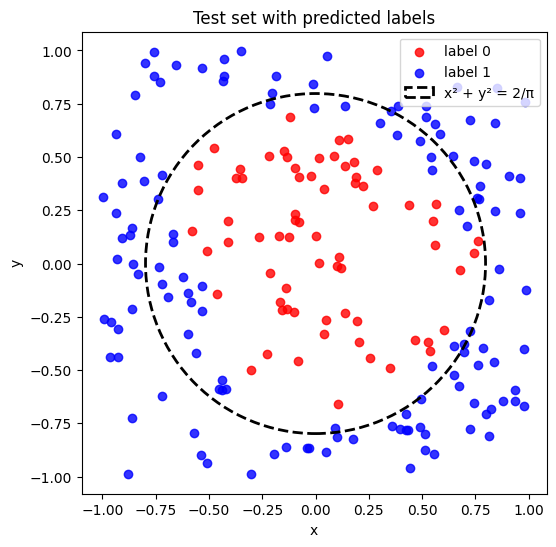

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(X_test[y_pred == 0][:, 0], X_test[y_pred == 0][:, 1], c="red", label="label 0", alpha=0.8)
plt.scatter(X_test[y_pred == 1][:, 0], X_test[y_pred == 1][:, 1], c="blue", label="label 1", alpha=0.8)
r = np.sqrt(2 / np.pi)
circle = plt.Circle((0, 0), r, color="black", fill=False, linestyle="--", linewidth=2, label="x² + y² = 2/π")
plt.gca().add_patch(circle)
plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Test set with predicted labels")
plt.legend()
plt.show()

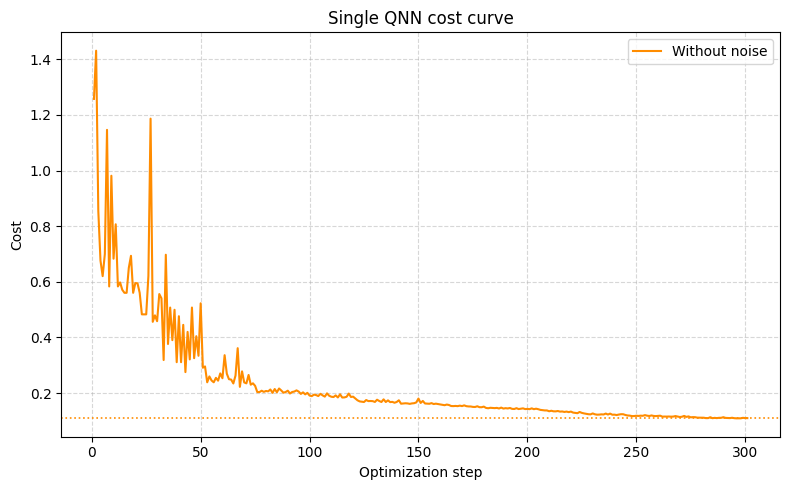

In [ ]:
plt.figure(figsize=(8, 5))
ax1 = plt.subplot(1, 1, 1)

ax1.plot(
    range(1, len(cost_history) + 1),
    cost_history,
    color="steelblue" if USE_NOISE else "darkorange",
    linewidth=1.5,
    label="With noise" if USE_NOISE else "Without noise"
)
ax1.axhline(
    res.fun,
    color="steelblue" if USE_NOISE else "darkorange",
    linestyle=":",
    linewidth=1.2
)

ax1.set_xlabel("Optimization step")
ax1.set_ylabel("Cost")
ax1.set_title("Single QNN cost curve")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend()

plt.tight_layout()
plt.show()


# AdaBoost Ensemble of Weak QNN Classifiers

AdaBoost trains `N_ESTIMATORS` QNNs sequentially. After each round the training sample weights are updated to emphasise the points that were misclassified, forcing the next estimator to focus on harder examples. The final prediction is a **weighted majority vote** over all estimators.

In [ ]:
def cost_fn_weighted_samples(params, X, y, sample_weights):
    theta = params[:3 * RC].reshape(RC, 3)
    omega = params[3 * RC:6 * RC].reshape(RC, 3)

    circuits = [create_circuit(x, theta, omega, measure=False) for x in X]
    probs = get_probs_batch(circuits)

    total = 0.0
    for i, y_t in enumerate(y):
        p0, p1 = probs[i]
        e0, e1 = (1.0, 0.0) if y_t == 0 else (0.0, 1.0)
        total += sample_weights[i] * ((p0 - e0) ** 2 + (p1 - e1) ** 2)

    return 0.5 * total / np.sum(sample_weights)


def optimize_weak_learner(X, y, sample_weights, seed):
    rng = np.random.default_rng(seed)
    init = rng.uniform(-np.pi, np.pi, size=6 * RC)

    res = minimize(
        cost_fn_weighted_samples,
        init,
        args=(X, y, sample_weights),
        method="COBYLA",
        options={"maxiter": MAXITER},
    )

    theta = res.x[:3 * RC].reshape(RC, 3)
    omega = res.x[3 * RC:].reshape(RC, 3)
    return theta, omega, res.fun


def train_adaboost(X_train, y_train, n_estimators=N_ESTIMATORS):
    n = len(y_train)
    weights = np.ones(n) / n
    estimators = []

    for i in range(n_estimators):
        theta, omega, cost = optimize_weak_learner(
            X_train, y_train, weights, seed=SEED + i
        )

        y_pred = predict_batch(X_train, theta, omega)
        incorrect = (y_pred != y_train).astype(float)
        eps = np.dot(weights, incorrect)
        eps = np.clip(eps, 1e-10, 1 - 1e-10)

        alpha = 0.5 * np.log((1 - eps) / eps)

        y_signed = np.where(y_train == 0, -1.0, 1.0)
        h_signed = np.where(y_pred == 0, -1.0, 1.0)
        weights *= np.exp(-alpha * y_signed * h_signed)
        weights /= np.sum(weights)

        estimators.append((theta, omega, alpha))
        print(f"round {i + 1:02d} | cost={cost:.4f} eps={eps:.4f} alpha={alpha:.4f}")

    return estimators


def predict_adaboost(X, estimators):
    scores = np.zeros(len(X))
    for theta, omega, alpha in estimators:
        h_signed = np.where(predict_batch(X, theta, omega) == 0, -1.0, 1.0)
        scores += alpha * h_signed
    return np.where(scores >= 0, 1, 0)


def evaluate_adaboost(X, y, estimators, positive_label=1):
    y_pred = predict_adaboost(X, estimators)
    tp = np.sum((y_pred == positive_label) & (y == positive_label))
    fp = np.sum((y_pred == positive_label) & (y != positive_label))
    fn = np.sum((y_pred != positive_label) & (y == positive_label))
    tn = np.sum((y_pred != positive_label) & (y != positive_label))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    accuracy = np.mean(y_pred == y)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return {
        "precision": precision,
        "accuracy": accuracy,
        "recall": recall,
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "tn": int(tn),
        "y_pred": y_pred,
    }

In [ ]:
mode_label = "Noisy" if USE_NOISE else "Noiseless"

print(f"=== AdaBoost ({mode_label.lower()}) ===")
estimators_boost = train_adaboost(X_train, y_train, n_estimators=N_ESTIMATORS)

metrics_boost = evaluate_adaboost(X_test, y_test, estimators_boost)
precision_boost = metrics_boost["precision"]
accuracy_boost = metrics_boost["accuracy"]
y_pred_boost = metrics_boost["y_pred"]

print("\nSingle QNN")
print(f"precision={precision_test:.4f} | accuracy={accuracy_test:.4f}")

print("\nAdaBoost")
print(f"precision={precision_boost:.4f} | recall={metrics_boost['recall']:.4f} | accuracy={accuracy_boost:.4f}")
print(
    f"TP={metrics_boost['tp']} FP={metrics_boost['fp']} "
    f"FN={metrics_boost['fn']} TN={metrics_boost['tn']}"
)

=== AdaBoost (noiseless) ===
round 01 | cost=0.0822 eps=0.0775 alpha=1.2384
round 02 | cost=0.1262 eps=0.1124 alpha=1.0332
round 03 | cost=0.1522 eps=0.1759 alpha=0.7721
round 04 | cost=0.1289 eps=0.1546 alpha=0.8495
round 05 | cost=0.1586 eps=0.2115 alpha=0.6579

Single QNN
precision=0.7634 | accuracy=0.8450

AdaBoost
precision=0.9897 | recall=0.9600 | accuracy=0.9750
TP=96 FP=1 FN=4 TN=99


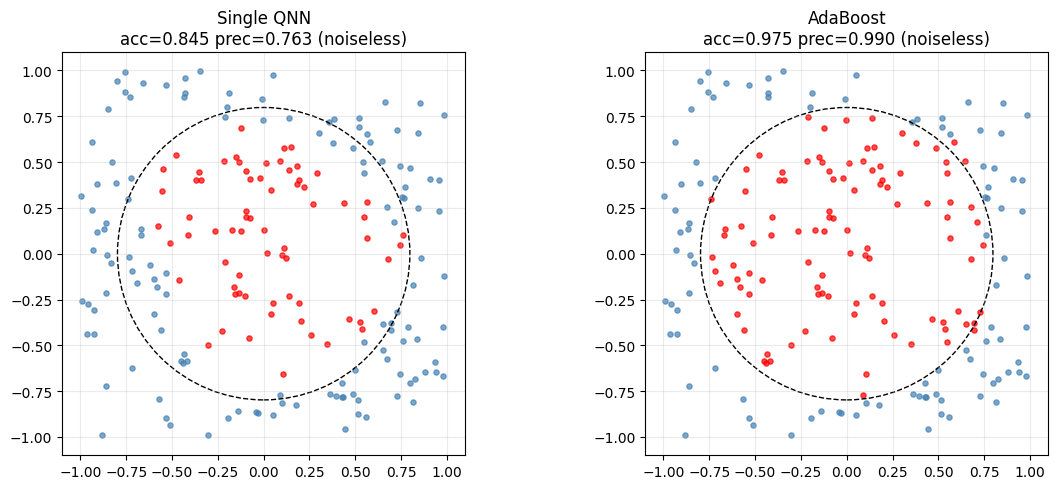

In [ ]:
r = np.sqrt(2 / np.pi)
mode_label = "Noisy" if USE_NOISE else "Noiseless"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plots = [
    (y_pred, f"Single QNN\nacc={accuracy_test:.3f} prec={precision_test:.3f}"),
    (y_pred_boost, f"AdaBoost\nacc={accuracy_boost:.3f} prec={precision_boost:.3f}"),
]

for ax, (pred, title) in zip(axes, plots):
    ax.scatter(X_test[pred == 0][:, 0], X_test[pred == 0][:, 1], c="red", s=14, alpha=0.7)
    ax.scatter(X_test[pred == 1][:, 0], X_test[pred == 1][:, 1], c="steelblue", s=14, alpha=0.7)
    ax.add_patch(plt.Circle((0, 0), r, color="black", fill=False, linestyle="--"))
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.25)
    ax.set_title(f"{title} ({mode_label.lower()})")

plt.tight_layout()
plt.show()